In [1]:
import pypsa
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# # creates conventional generators with generator components
# n = pypsa.Network(name="test_case")

# n.set_snapshots(range(24))

# n.madd("Bus", ["generation_bus", "load_bus", "renewable_bus"], carrier="electricity", v_nom=500)

# n.add("Generator", name="coal plant", bus="generation_bus", p_nom=300, p_min_pu=0.167, committable=True, marginal_cost=3)
# n.add("Generator", name="gas plant", bus="generation_bus", p_nom=400, p_min_pu=0.25, committable=True, marginal_cost=4)
# n.add("Generator", name="solar plant", bus="renewable_bus", p_nom=200, marginal_cost=0, carrier="electricity")
# n.add("Load", name="load", bus="load_bus", p_set=500)

# # set generation availability for solar plant 
# n.generators_t.p_max_pu["solar plant"] = solar_availability

# # alternative ways of defining the link
# # option A: capital expansion with no cost - p_nom_max and p_nom_extendable = True
# # option B: fixed capacity - p_nom 
# # x = 0.3 ohms per mi reactance reference (lazy 2:1 km:mi conversion)
# n.add("Line", name="conv_load", bus0="generation_bus", bus1="load_bus", s_nom=1000, carrier="electricity", x=0.15)
# n.add("Line", name="conv_renwable", bus0="renewable_bus", bus1="generation_bus", s_nom=1000, carrier="electricity", x=0.15)
# n.add("Line", name="renewable_load", bus0="renewable_bus", bus1="load_bus", s_nom=1000, carrier="electricity", x=0.15)


In [34]:
# creates conventional generators with link components as in pypsa-eur
n = pypsa.Network(name="test_case")

n.set_snapshots(range(24))
solar_availability = np.clip((-np.cos(n.snapshots / 24 * 2 * np.pi)*0.75 + 0.25), 0, 1)

n.madd("Bus", ["generation_bus", "load_bus", "renewable_bus"], carrier="electricity", v_nom=500)
n.madd("Bus", ["coal", "gas"], carrier=["coal", "gas"])
n.madd("Bus", ["thermal_generation_bus","thermal_bus"], carrier='heat')
n.add("Bus", "emissions", carrier="carbon")

# set at arbitarily high e_nom to represent stockpile 
n.add("Store", name="coal", bus="coal", e_nom=1e10, e_initial=1e10, e_cyclic=False)
n.add("Store", name="gas", bus="gas", e_nom=1e10, e_initial=1e10, e_cyclic=False)

# make somewhere for the carbon to go
n.add("Store", name="co2 atmosphere", bus="emissions", carrier="carbon", e_nom=1e10, e_initial=0, e_cyclic=False)

# add conventional generators with link components so we can see fuel consumption
n.add("Link", name="coal plant", bus0="coal", bus1="generation_bus", p_nom=300, p_min_pu=0.167, committable=True, marginal_cost=3)

# make the gas plant into a CHP 
n.add("Link", name="gas plant", bus0="gas", bus1="generation_bus", bus2="thermal_generation_bus", efficiency=0.8, efficiency2=0.2, p_nom=600, p_min_pu=0.25, committable=True, marginal_cost=4)

# add renewable generator with generator component (no fuel to track)
n.add("Generator", name="solar plant", bus="renewable_bus", p_nom=200, p_min_pu=0, marginal_cost=0, carrier="electricity")

n.add("Load", name="load", bus="load_bus", p_set=500, carrier='electricity')
n.add("Load", name="thermal_load", bus="thermal_bus", p_set=10, carrier='heat')
n.add("Store", name="thermal_sink", bus="thermal_bus", e_nom=1e10, carrier='heat')

# set generation availability for solar plant 
n.generators_t.p_max_pu["solar plant"] = solar_availability

# x = 0.3 ohms per mi reactance reference (lazy 2:1 km:mi conversion, assume 1km (so r/x is unitized))
n.add("Line", name="conv_load", bus0="generation_bus", bus1="load_bus", s_nom=1000, carrier="electricity", x=0.15, r=0.1)
n.add("Line", name="renewable_conv", bus0="renewable_bus", bus1="generation_bus", s_nom=1000, carrier="electricity", x=0.15, r=0.1)
n.add("Line", name="renewable_load", bus0="renewable_bus", bus1="load_bus", s_nom=1000, carrier="electricity", x=0.15, r=0.1)

n.add("Link", name="steam_pipe", bus0="thermal_generation_bus", bus1="thermal_bus", p_nom=1000, carrier="heat")

In [35]:
print(n.links.loc["gas plant", ["efficiency", "efficiency2"]])

attribute
efficiency     0.8
efficiency2    0.2
Name: gas plant, dtype: object


In [36]:
n.optimize()

Index(['generation_bus', 'load_bus', 'renewable_bus', 'coal', 'gas',
       'thermal_generation_bus', 'thermal_bus', 'emissions'],
      dtype='object', name='Bus')
Index(['solar plant'], dtype='object', name='Generator')
Index(['conv_load', 'renewable_conv', 'renewable_load'], dtype='object', name='Line')
Index(['coal plant', 'gas plant', 'steam_pipe'], dtype='object', name='Link')
Index(['coal', 'gas', 'co2 atmosphere', 'thermal_sink'], dtype='object', name='Store')
Index(['load', 'thermal_load'], dtype='object', name='Load')
Index(['generation_bus', 'load_bus', 'renewable_bus', 'coal', 'gas',
       'thermal_generation_bus', 'thermal_bus', 'emissions'],
      dtype='object', name='Bus')
Index(['solar plant'], dtype='object', name='Generator')
Index(['conv_load', 'renewable_conv', 'renewable_load'], dtype='object', name='Line')
Index(['coal plant', 'gas plant', 'steam_pipe'], dtype='object', name='Link')
Index(['coal', 'gas', 'co2 atmosphere', 'thermal_sink'], dtype='object', name='S

Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  linopy-problem-xgy3jpon has 936 rows; 504 cols; 1696 nonzeros; 144 integer variables (144 binary)
Coefficient ranges:
  Matrix [4e-02, 6e+02]
  Cost   [3e+00, 4e+00]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 1e+10]
Presolving model
298 rows, 195 cols, 678 nonzeros  0s
136 rows, 137 cols, 406 nonzeros  0s
118 rows, 103 cols, 320 nonzeros  0s
88 rows, 103 cols, 278 nonzeros  0s

Solving MIP model with:
   88 rows
   103 cols (14 binary, 0 integer, 0 implied int., 89 continuous, 0 domain fixed)
   278 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; J => Feasibility jump;
     H => Heuristic; L => Sub-MIP; P => Empty MIP; R => Randomized rounding; Z => ZI Round;
     I => Shifting; S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |

('ok', 'optimal')

In [37]:
n.statistics.supply(comps=['Link', 'Generator'],aggregate_time=False)

snapshot                  0      1      2      3      4          5      6   \
component carrier                                                            
Link      coal         300.0  300.0  300.0  300.0  300.0  300.00000  300.0   
          gas          250.0  250.0  250.0  250.0  250.0  236.02857  187.5   
          heat          50.0   50.0   50.0   50.0   50.0   47.20571   37.5   
Generator electricity    NaN    NaN    NaN    NaN    NaN   11.17714   50.0   

snapshot                      7      8          9   ...         14         15  \
component carrier                                   ...                         
Link      coal         291.17714  255.0  223.93398  ...  200.09619  223.93398   
          gas          150.00000  150.0  150.00000  ...  150.00000  150.00000   
          heat          30.00000   30.0   30.00000  ...   30.00000   30.00000   
Generator electricity   88.82286  125.0  156.06602  ...  179.90381  156.06602   

snapshot                  16         17     18         19     20     21  \
component carrier                                                         
Link      coal         255.0  291.17714  300.0  300.00000  300.0  300.0   
          gas          150.0  150.00000  187.5  236.02857  250.0  250.0   
          heat          30.0   30.00000   37.5   47.20571   50.0   50.0   
Generator electricity  125.0   88.82286   50.0   11.17714    NaN    NaN   

snapshot                  22     23  
component carrier                    
Link      coal         300.0  300.0  
          gas          250.0  250.0  
          heat          50.0   50.0  
Generator electricity    NaN    NaN  

[4 rows x 24 columns]

In [38]:
n.statistics.transmission(aggregate_time=False)

,snapshot,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
component,carrier,,,,,,,,,,,,,,,,,,,,,
Line,electricity,333.33333,333.33333,333.33333,333.33333,333.33333,340.78476,366.66667,392.54857,416.66667,437.37734,...,453.26921,437.37734,416.66667,392.54857,366.66667,340.78476,333.33333,333.33333,333.33333,333.33333
Link,heat,50.00000,50.00000,50.00000,50.00000,50.00000,47.20571,37.50000,30.00000,30.00000,30.00000,...,30.00000,30.00000,30.00000,30.00000,37.50000,47.20571,50.00000,50.00000,50.00000,50.00000


<Axes: xlabel='snapshot'>

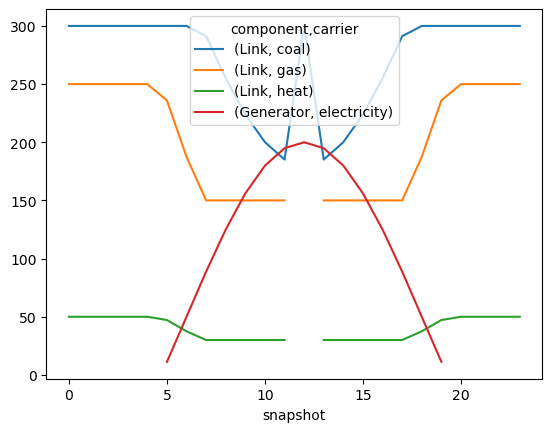

In [39]:
n.statistics.supply(aggregate_time=False, comps=['Link', 'Generator']).T.plot()

In [40]:
n.lines_t.p0

Line,conv_load,renewable_conv,renewable_load
snapshot,,,
0,333.333333,-166.666667,166.666667
1,333.333333,-166.666667,166.666667
2,333.333333,-166.666667,166.666667
3,333.333333,-166.666667,166.666667
4,333.333333,-166.666667,166.666667
5,329.607619,-159.215238,170.392381
6,316.666667,-133.333333,183.333333
7,303.725714,-107.451429,196.274286
8,291.666667,-83.333333,208.333333


In [ ]:
n.lines_t.p1

Line,conv_load,renewable_conv,renewable_load
snapshot,,,
0,-333.333333,166.666667,-166.666667
1,-333.333333,166.666667,-166.666667
2,-333.333333,166.666667,-166.666667
3,-333.333333,166.666667,-166.666667
4,-333.333333,166.666667,-166.666667
5,-329.607619,159.215238,-170.392381
6,-316.666667,133.333333,-183.333333
7,-303.725714,107.451429,-196.274286
8,-291.666667,83.333333,-208.333333


In [ ]:
# for debugging purposes 
n.model.to_file("test.lp")

In [29]:
n.links_t.p1

Link,coal plant,gas plant,steam_pipe
snapshot,,,
0,-300.000000,-200.000000,0.0
1,-300.000000,-200.000000,0.0
2,-300.000000,-200.000000,0.0
3,-300.000000,-200.000000,0.0
4,-300.000000,-200.000000,0.0
5,-300.000000,-188.822857,0.0
6,-300.000000,-150.000000,0.0
7,-291.177143,-120.000000,0.0
8,-255.000000,-120.000000,0.0
